In [1]:
import os
import base64
import requests
import glob
import random
import decord
import json
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from deployment.src.gpt4v import BaseO4Mini

load_dotenv() # Loads openai key

True

In [2]:
model = BaseO4Mini(
    api_key_env_var="OPENAI_API_KEY", 
    model_name="gpt-4o-mini-2024-07-18"
)

Selected video: ../../data/fai_spinflow_processed/output_rides_2025-08-08-13-13-00/ride_ferrite7_2025-08-08-13-14-48_0/seq_4144/front_camera.mp4


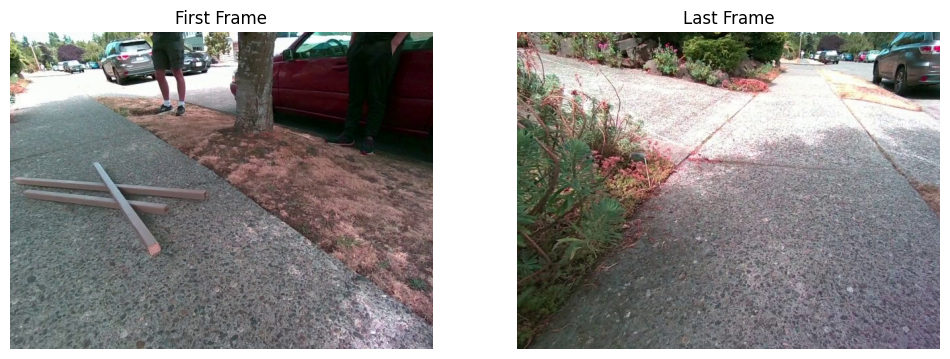

In [3]:
%matplotlib inline
video_dir = "../../data/fai_spinflow_processed/"
videos = glob.glob(os.path.join(video_dir, "**", "front_camera.mp4"), recursive=True)
video_path = random.choice(videos)
print(f"Selected video: {video_path}")

decord.bridge.set_bridge("torch")
vr = decord.VideoReader(str(video_path))

# img = Image.fromarray(img).convert("RGB")  # Convert to PIL Image
last_img = vr.get_batch(range(0, 1))
last_img_np = last_img.numpy()[0]

first_img = vr.get_batch(range(len(vr) - 1, len(vr)))
first_img_np = first_img.numpy()[0]
Image.fromarray(first_img_np).convert("RGB").save("openai_test.jpg")

stacked_img = np.stack([last_img_np, first_img_np], axis=0)
img = Image.fromarray(stacked_img[0]).convert("RGB")  # Convert to PIL Image

# Plot first and last image side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(first_img_np)
plt.title("First Frame")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(last_img_np)
plt.title("Last Frame")
plt.axis("off")
plt.show()

In [4]:
SYSTEM_PROMPT = """
You are a helpful assistant that understands an image and a caption describing the future behavior of a robot taking the image.
Your task is to generate 10 variations of the caption that are natural and contextually relevant, while maintaining the original meaning and spatial relationships described in the caption.
You should provide the variations in a json file of this form:
{{"scene_captions": [<caption variation 1>, <caption variation 2>, ..., <caption variation 10>]}}
"""

user_prompt = """
Caption:
Avoid the black backpack and drive around from the left side while staying on the sidewalk.
"""
full_prompt = SYSTEM_PROMPT + user_prompt

# Try to generate text up to 10 times and check if it is a valid json
model_result = None
num_tries = 0

while model_result is None and num_tries < 10:
    try:
        json_response = model.generate_text_individual(
            text=full_prompt,
            image_filepaths=["openai_test.jpg"],
        )
        model_result = model.parse_response(json_response, expected_key="scene_captions")
        if len(model_result) < 10:
            raise json.JSONDecodeError("Not enough caption variations generated")
    except json.JSONDecodeError:
        print(f"Attempt {num_tries + 1}: Failed to parse JSON response. Retrying...")
        model_result = None
        num_tries += 1

last_usage_info = model.last_usage_info
print("Model result :", model_result)

Model result : ['Steer clear of the black backpack and navigate around it from the left while remaining on the sidewalk.', 'Circumvent the black backpack and approach from the left side, ensuring you stay on the sidewalk.', 'Avoid driving over the black backpack and go around it to the left, all while staying on the sidewalk.', 'Keep away from the black backpack and make your way around it from the left, staying on the sidewalk.', 'Take the left side to bypass the black backpack while keeping to the sidewalk.', 'Navigate from the left side to avoid the black backpack, making sure to stay on the sidewalk.', 'Bypass the black backpack by moving around from the left side while remaining on the sidewalk.', 'Drive left around the black backpack while ensuring you stay on the sidewalk.', 'Avoid the black backpack and proceed around it from the left, adhering to the sidewalk.', 'Circumvent the black backpack and move from the left side while staying on the paved path.']


In [5]:
print("Last usage info:", last_usage_info)
cost_per_input_token = 0.15
cost_per_output_token = 0.60

scale = 1e6  # Scale to convert tokens to millions
prompt_tokens = last_usage_info['prompt_tokens'] / scale
completion_tokens = last_usage_info['completion_tokens'] / scale

total_cost = prompt_tokens * cost_per_input_token + \
    completion_tokens * cost_per_output_token
print(f"Total cost for the request: ${total_cost:.4f}")

total_estimated_request = 9000 * 3 * total_cost
print(f"Estimated cost for 8000 requests: ${total_estimated_request:.4f}")

Last usage info: {'prompt_tokens': 14291, 'completion_tokens': 220, 'total_tokens': 14511, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}}
Total cost for the request: $0.0023
Estimated cost for 8000 requests: $61.4426
